<a href="https://colab.research.google.com/github/Vinodini1234/data-analysis/blob/main/Banking_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Banking fraud detection
# data analysis
import statistics
import pandas as pd
import matplotlib.pyplot as plt
tran_amt=[20000,45970,67840,12000,32000,43990,31490,23000]
loct=["kadapa","rayachoty","chithur","kadapa","kadapa","tirupathi","rayachoty","kadapa"]
time=[1.20,2.00,5.12,1.30,1.25,4.16,2.10,1.10]
act_active=["active","active","active","block","block","block","active","block"]
data=pd.DataFrame({
    'transaction amount':tran_amt,
    'location':loct,
    'time':time,
    'activity':act_active
})
print(data)

   transaction amount   location  time activity
0               20000     kadapa  1.20   active
1               45970  rayachoty  2.00   active
2               67840    chithur  5.12   active
3               12000     kadapa  1.30    block
4               32000     kadapa  1.25    block
5               43990  tirupathi  4.16    block
6               31490  rayachoty  2.10   active
7               23000     kadapa  1.10    block


In [4]:
# finding of unusual transaction
avg_tran_amt=statistics.mean(tran_amt)
print("average transaction amount:",avg_tran_amt)
unusual_transaction=data['transaction amount']>avg_tran_amt
print("\n unusual transactions:")
print(unusual_transaction)

average transaction amount: 34536.25

 unusual transactions:
0    False
1     True
2     True
3    False
4    False
5     True
6    False
7    False
Name: transaction amount, dtype: bool


In [7]:
# finding high risk account
high_risk_account=data['activity']=='block'
print("\n high risk account:")
print(high_risk_account)


 high risk account:
0    False
1    False
2    False
3     True
4     True
5     True
6    False
7     True
Name: activity, dtype: bool


In [12]:
# identifing fraud patterns
f_p=[]
for i in range(len(time)):
  if data['activity'][i]=='block':
    f_p.append(i)
  elif data['activity'][i]=='block' and data['time'][i]>2:
    f_p.append(i)
  elif tran_amt[i]>avg_tran_amt and data['time'][i]>2:
    f_p.append(i)
print("\n fraud patterns:")
print(f_p)


 fraud patterns:
[2, 3, 4, 5, 7]


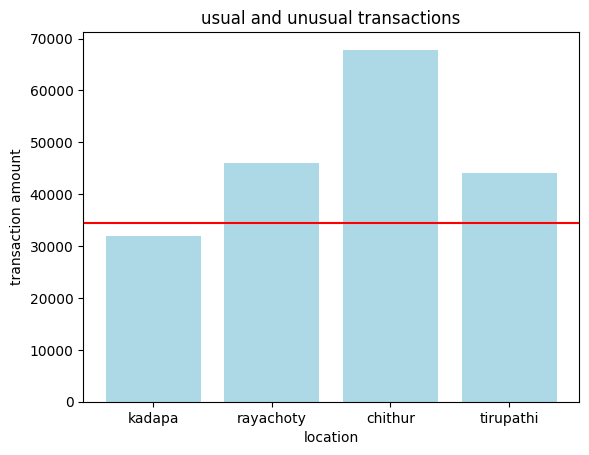

In [16]:
# chart for usual and unusual transactions
plt.bar(loct, tran_amt, color='lightblue')
plt.axhline(y=avg_tran_amt,color='red',linestyle='-')
plt.xlabel('location')
plt.ylabel('transaction amount')
plt.title('usual and unusual transactions')
plt.show()

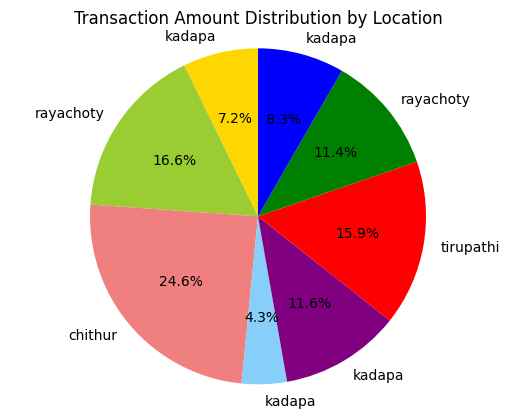

In [21]:
# pie chart for location and transaction amount
labels=loct
sizes=tran_amt
colors=['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'purple', 'red', 'green', 'blue']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Transaction Amount Distribution by Location')
plt.show()